# InterScale Pipeline: Local Model

Local Model = Graph Convolutional Neural Network

Data: Legnini et. al. 

In [1]:
import scanpy as sc

import InterScale as interscale
from InterScale.config import load_config
from graph_transformer_long_range_niches.pp import split_adata
from InterScale.tl import prepare_geome_dataset, check_and_update_cfg
from InterScale.geome_dataloader import GraphAnnDataModule

# from graph_transformer_long_range_niches.config import load_config
# from graph_transformer_long_range_niches.pp import sliding_window

/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Imp

In [21]:
CFG_PATH_GRAPH = "/home/icb/francesca.drummer/1-Projects/GT-long-range-niches/src/config_files/Legnini_23/legnini23_graph_sample_LocalModel_gnn.yaml"
CFG_PATH_REG = "/home/icb/francesca.drummer/1-Projects/GT-long-range-niches/src/config_files/Legnini_23/legnini23_genes_sample_LocalModel.yaml"

## 0. Load and prepare data

We load a subset of the CosmX pancreas data containing T1D (type 1 diabetes) and ND (no diabetes) samples and the config file with the model specifications. 

In [22]:
cfg = load_config(CFG_PATH_GRAPH)
cfg

CfgNode({'wandb': CfgNode({'use': True, 'project_name': 'GTLongRange_Legnini23'}), 'model': CfgNode({'n_embed': 32, 'local_component': CfgNode({'name': 'GCN', 'load': None, 'parameters': CfgNode({'embed_dim': 32, 'hidden_dim': 64, 'num_layers': 2, 'dropout_local': 0.0})}), 'global_component': CfgNode({'name': 'self-attn-transformer', 'load': None, 'parameters': CfgNode({'n_heads': 4, 'dim_feedforward': 128, 'dropout_global': 0.0, 'activation_func': 'relu', 'num_layers': 2, 'max_seq_len': 2000, 'long_range_attention': True})}), 'save': None, 'loss': 'GaussianNLL', 'decoder': CfgNode({'type': 'linear', 'hidden_dims': [256, 128], 'dropout_decoder': 0.1})}), 'optim': CfgNode({'lr': 0.001, 'wd': 0.0, 'lr_warmup': 20, 'loss': 'CrossEntropy', 'seed': 44, 'cross_corr': 'gene', 'n_epochs': 4000}), 'dataset': CfgNode({'h5ad_data': '/lustre/groups/ml01/projects/2024_spatial_long_range_GT_francesca.drummer/data/legnini23.h5ad', 'name': 'legnini23', 'description': '', 'prediction_task': 'classifica

In [23]:
DATA_PATH = '/lustre/groups/ml01/projects/2024_spatial_long_range_GT_francesca.drummer/data/legnini23.h5ad'

In [24]:
adata = sc.read_h5ad(DATA_PATH)
adata

AnnData object with n_obs × n_vars = 43762 × 88
    obs: 'Cell', 'Area', 'x', 'y', 'sample', 'condition', 'organoid', 'obs_names', 'split'
    var: 'gene_ids', 'feature_types'
    obsm: 'spatial'
    layers: 'log1p_norm', 'norm_ftsqrt', 'raw'

In [25]:
import pandas as pd
# Creating a DataFrame from 'split', 'fov', and 'condition'
df = adata.obs[['split', 'sample', 'condition']]
value_counts = pd.DataFrame(df.values, columns=df.columns).value_counts()
print(value_counts)

split  sample       condition
train  slide1_D2-2  SHH          4318
       slide1_D2-3  SHH          3621
       slide1_C2-2  SHH          3510
       slide4_B2-1  SHH          3345
val    slide1_B2-1  SHH          3299
train  slide1_A2-1  SHH          3023
       slide1_C2-1  Ctrl         2870
       slide4_A2-1  SHH          2630
       slide4_A2-2  SHH          2506
val    slide1_B2-3  SHH          2241
test   slide4_A2-3  Ctrl         1984
train  slide1_C2-5  Ctrl         1958
test   slide4_B2-2  SHH          1779
train  slide1_B2-2  Ctrl         1701
val    slide1_A2-2  SHH          1694
       slide4_B2-3  Ctrl         1643
       slide1_C2-3  Ctrl         1640
Name: count, dtype: int64


## 1. Data setup

We need to specify:

- `prediction_task`: Prediction task can either be classification or regression
- `prediction_level`: Which level the predictions should be performed on: either (1) tissue label, e.i. condition (`graph`), (2) node label (`node`) for cell type or niche prediciton, or (3) GEX prediction.

Additionally, we define dataset specific keys: 
- `prediction_obs`: Label in `adata.obs` to be predicted. Only required for classification tasks.
- `layer_key`: Defines which GEX matrix to retrieve from `adata.layer`
- `sample_key`: `adata.obs` used to split the samples into PyG Data objects
- `group_label`: Optional: only if we have a `adata.obs` group that we want to stratify during sampling

In [26]:
PREDICTION_TASK = 'classification'
PREDICTION_LEVEL = 'graph'

prediction_obs = 'condition'
layer_key = 'log1p_norm'
sample_key = 'sample'
group_label = 'condition'

In [27]:
cfg = check_and_update_cfg(cfg, prediction_task = PREDICTION_TASK, prediction_level = PREDICTION_LEVEL, layer_key = layer_key, sample_key = sample_key, prediction_obs = prediction_obs)

Update group label (from 'condition' to 'None')


In [28]:
interscale.model.LocalModel._setup_anndata(adata = adata, prediction_task = PREDICTION_TASK, layer_key = layer_key, sample_key = sample_key, prediction_obs = prediction_obs, group_key = group_label)

/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.layers[log1p_norm] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


Anndata setup with scvi-tools version 1.3.0.

     Summary Statistics     
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Summary Stat Key ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│   n_group_key    │   2   │
│ n_prediction_obs │   2   │
│   n_sample_key   │  17   │
│       n_x        │  88   │
└──────────────────┴───────┘

                    Data Registry                     
┏━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃  Registry Key  ┃        scvi-tools Location        ┃
┡━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│   group_key    │   adata.obs['_scvi_group_key']    │
│ prediction_obs │ adata.obs['_scvi_prediction_obs'] │
│   sample_key   │   adata.obs['_scvi_sample_key']   │
│       x        │    adata.layers['log1p_norm']     │
└────────────────┴───────────────────────────────────┘

                 sample_key State Registry                 
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃   Source Location   ┃ Categories  ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['sample'] │ slide1_A2-1 │          0          │
│                     │ slide1_A2-2 │          1          │
│                     │ slide1_B2-1 │          2          │
│                     │ slide1_B2-2 │          3          │
│                     │ slide1_B2-3 │          4          │
│                     │ slide1_C2-1 │          5          │
│                     │ slide1_C2-2 │          6          │
│                     │ slide1_C2-3 │          7          │
│                     │ slide1_C2-5 │          8          │
│                     │ slide1_D2-2 │          9          │
│                     │ slide1_D2-3 │         10          │
│                     │ slide4_A2-1 │         11          │
│                     │ slide4_A2-2 │         12          │
│                     │ slide4_A2-3 │         13          │
│                     │ slide4_B2-1 │         14          │
│                     │ slide4_B2-2 │         15          │
│                     │ slide4_B2-3 │         16          │
└─────────────────────┴─────────────┴─────────────────────┘

                prediction_obs State Registry                
┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃    Source Location     ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['condition'] │    Ctrl    │          0          │
│                        │    SHH     │          1          │
└────────────────────────┴────────────┴─────────────────────┘

                  group_key State Registry                   
┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃    Source Location     ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['condition'] │    Ctrl    │          0          │
│                        │    SHH     │          1          │
└────────────────────────┴────────────┴─────────────────────┘

In [29]:
adata

AnnData object with n_obs × n_vars = 43762 × 88
    obs: 'Cell', 'Area', 'x', 'y', 'sample', 'condition', 'organoid', 'obs_names', 'split', '_scvi_sample_key', '_scvi_prediction_obs', '_scvi_group_key'
    var: 'gene_ids', 'feature_types'
    uns: '_scvi_uuid', '_scvi_manager_uuid'
    obsm: 'spatial'
    layers: 'log1p_norm', 'norm_ftsqrt', 'raw'

## 2. Model setup

In [30]:
model = interscale.model.LocalModel(
    adata,
    cfg = cfg
)

In [31]:
model._model_summary_string

'classification model for graph prediction. \nLocal component GCN: n_layers: 2,n_hidden: 64,n_embed: 32, dropout_local: 0.0'

## 3. Training

In [32]:
#split_adata(adata, split_obs='sample', val_size=cfg.dataset.val_size, test_size=cfg.dataset.test_size, seed = cfg.optim.seed, stratify_groups = cfg.dataset.group_label)
pyg_data_list, _ = prepare_geome_dataset(adata, cfg)
dm = GraphAnnDataModule(datas=pyg_data_list, 
                           num_workers=1, 
                           batch_size=int(cfg.dataset.batch_size), 
                           pct_mask_nodes=cfg.dataset.pct_mask_nodes,
                           learning_type="node")

Split key split already exists in adata.obs
coord_type: generic
library_key: sample
n_neighs: 6
radius: 200
call new
{'condition': ['Ctrl', 'SHH']}


/ictstr01/home/icb/francesca.drummer/1-Projects/geome/src/geome/transforms/categorize.py:38: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  getattr(adata, self.axis)[key] = getattr(adata, self.axis)[key].astype("category")


call new
{'condition': ['Ctrl', 'SHH']}


/ictstr01/home/icb/francesca.drummer/1-Projects/geome/src/geome/transforms/categorize.py:38: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  getattr(adata, self.axis)[key] = getattr(adata, self.axis)[key].astype("category")


call new
{'condition': ['Ctrl', 'SHH']}
call new
{'condition': ['Ctrl', 'SHH']}


/ictstr01/home/icb/francesca.drummer/1-Projects/geome/src/geome/transforms/categorize.py:38: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  getattr(adata, self.axis)[key] = getattr(adata, self.axis)[key].astype("category")
/ictstr01/home/icb/francesca.drummer/1-Projects/geome/src/geome/transforms/categorize.py:38: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  getattr(adata, self.axis)[key] = getattr(adata, self.axis)[key].astype("category")


Masked dataloader


In [33]:
dm.setup("fit")

In [34]:
for batch in dm.val_dataloader(): 
    print(batch)

DataBatch(x=[7234, 88], edge_index=[2, 77146], y=[7234, 2], obs_names=[7234], mask=[7234], batch=[7234], ptr=[4])
DataBatch(x=[3283, 88], edge_index=[2, 32096], y=[3283, 2], obs_names=[3283], mask=[3283], batch=[3283], ptr=[3])


In [35]:
# for now training only works with datamodule. TODO: Add DataSplitter for datamodule independent training.
model.train(max_epochs = 50, 
           datamodule = dm,
           early_stopping = True)

/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /ictstr01/groups/ml01/workspace/francesca.drummer/ma ...
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:654: Checkpoint directory /ictstr01/home/icb/francesca.drummer/1-Projects/GT-long-range-niches/docs/notebooks/lightning_logs/version_36257564/checkpoints exists and is not empty.

  | Name    | Type      

torch.Size([6633, 2]) torch.Size([6633, 2])
torch.Size([3884, 2]) torch.Size([3884, 2])


/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=5` in the `DataLoader` to improve performance.


torch.Size([10154, 2]) torch.Size([10154, 2])
torch.Size([9818, 2]) torch.Size([9818, 2])
torch.Size([7552, 2]) torch.Size([7552, 2])
torch.Size([1958, 2]) torch.Size([1958, 2])
torch.Size([6582, 2]) torch.Size([6582, 2])
torch.Size([3935, 2]) torch.Size([3935, 2])
torch.Size([9485, 2]) torch.Size([9485, 2])
torch.Size([6529, 2]) torch.Size([6529, 2])
torch.Size([9150, 2]) torch.Size([9150, 2])
torch.Size([4318, 2]) torch.Size([4318, 2])
torch.Size([7234, 2]) torch.Size([7234, 2])
torch.Size([3283, 2]) torch.Size([3283, 2])
torch.Size([8782, 2]) torch.Size([8782, 2])
torch.Size([8845, 2]) torch.Size([8845, 2])
torch.Size([8345, 2]) torch.Size([8345, 2])
torch.Size([3510, 2]) torch.Size([3510, 2])
torch.Size([7234, 2]) torch.Size([7234, 2])
torch.Size([3283, 2]) torch.Size([3283, 2])
torch.Size([9596, 2]) torch.Size([9596, 2])
torch.Size([7077, 2]) torch.Size([7077, 2])
torch.Size([10851, 2]) torch.Size([10851, 2])
torch.Size([1958, 2]) torch.Size([1958, 2])
torch.Size([6582, 2]) torch.

`Trainer.fit` stopped: `max_epochs=50` reached.


torch.Size([7183, 2]) torch.Size([7183, 2])
torch.Size([3334, 2]) torch.Size([3334, 2])
torch.Size([6636, 2]) torch.Size([6636, 2])
torch.Size([3881, 2]) torch.Size([3881, 2])


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│          val_acc          │    0.9492764472961426     │
│      val_f1/class_0       │    0.8836426138877869     │
│      val_f1/class_1       │    0.9666299223899841     │
│     val_f1_macro/avg      │    0.9251362681388855     │
│     val_f1_micro/avg      │    0.9492764472961426     │
│         val_loss          │    0.1468728929758072     │
└───────────────────────────┴───────────────────────────┘

/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:476: Your `test_dataloader`'s sampler has shuffling enabled, it is strongly recommended that you turn shuffling off for val/test dataloaders.
/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=5` in the `DataLoader` to improve performance.


torch.Size([3763, 2]) torch.Size([3763, 2])


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.9181504249572754     │
│      test_f1/class_0      │    0.9160763621330261     │
│      test_f1/class_1      │    0.9201244711875916     │
│     test_f1_macro/avg     │    0.9181003570556641     │
│     test_f1_micro/avg     │    0.9181504249572754     │
│         test_loss         │    0.21856558322906494    │
└───────────────────────────┴───────────────────────────┘

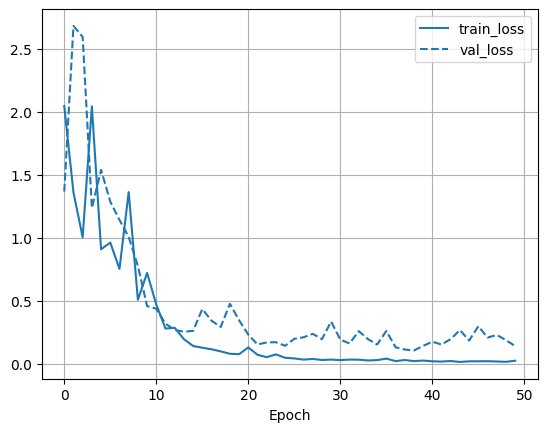

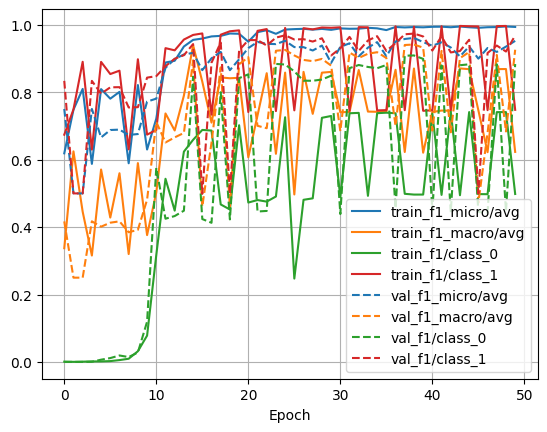

TypeError: no numeric data to plot

In [37]:
model.history_.plot_history(subset_term = 'loss')
model.history_.plot_history(subset_term = 'f1')
model.history_.plot_history(subset_term = 'r2')

## 4. Evaluation

Evaluation can either be run on the entire AnnData that the model was set up with or subsets of AnnData defined by sample_id from `adata.obs[sample_key]`.

In [38]:
sub_adata = adata[adata.obs['condition'] == 'SHH']

In [39]:
result = model.get_model_output(sub_adata)

INFO     Received view of anndata, making copy.                                                                    
coord_type: generic
library_key: sample
n_neighs: 6
radius: 200
call new
{'condition': ['SHH']}


/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.layers[log1p_norm] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


In [40]:
result

AnnData object with n_obs × n_vars = 31966 × 88
    obs: 'Cell', 'Area', 'x', 'y', 'sample', 'condition', 'organoid', 'obs_names', 'split', '_scvi_sample_key', '_scvi_prediction_obs', '_scvi_group_key'
    var: 'gene_ids', 'feature_types'
    uns: '_scvi_uuid', '_scvi_manager_uuid', 'one_hot_mappings'
    obsm: 'spatial', 'one_hot', 'local_emb', 'decoder_weight'
    layers: 'log1p_norm', 'norm_ftsqrt', 'raw'

### Tissue level analysis

Can we detect a pattern across cells in which are more and less relevant to predict the condition? 

No cell types so need to categorize them differently. 

1. SHH expressed or not (Distance to SHH source)
2. What analysis could we perform without knowing that the SHH is the source for variation? Can we somehow trace the changes back to genes? 

In [ ]:
# plot celltype x condition 
import pandas as pd

def summarise_decoder_weight_by_group_and_condition(
    adata, 
    group_obs: str,
    condition_obs: str = '_scvi_prediction_obs', 
    decoder_weight_key: str = 'decoder_weight', 
):
    """
    Summarizes average attention weights for each (group_obs x condition_obs) combination.
    
    Parameters
    ----------
    adata : AnnData
        AnnData object containing attention weights in adata.obsm[decoder_weight_key].
    decoder_weight_key : str
        Key for the attention weight matrix in adata.obsm.
    condition_obs : str
        Column name in adata.obs for condition (e.g., 'disease_status').
    group_obs : str
        Column name in adata.obs for group (e.g., 'cell_type').
        
    Returns
    -------
    pd.DataFrame
        Multi-index DataFrame with average attention weights for each group x condition.
        Rows: (group_obs, condition_obs)
        Columns: attention per target cell type (from decoder_weight_key).
    """
    # Extract relevant data
    weight = adata.obsm[decoder_weight_key]
    group = adata.obs[group_obs]
    condition = adata.obs[condition_obs]
    
    # Create DataFrame for easy grouping
    df = pd.DataFrame(
        weight, 
        columns=[f"{decoder_weight_key}_{i}" for i in range(weight.shape[1])]
    )
    df[group_obs] = group.values
    df[condition_obs] = condition.values
    
    # Group by group_obs and condition_obs, then average
    grouped = df.groupby([group_obs, condition_obs]).mean()
    
    return grouped

In [ ]:
summarise_decoder_weight_by_group_and_condition(
    result, 
    condition_obs = 'shh_cluster', 
    group_obs = 'condition'
)

In [ ]:
data_list